In [29]:
from classes import dane as classes
import random as rnd
import pandas as pd
import math
import copy
import matplotlib.pyplot as plt
from typing import Callable

In [30]:
start_schedule = {subject: rnd.choice(options) for subject, options in classes.items()}
start_schedule

{'Analiza czasu trwania': {'id': 6,
  'lecturer': 'Wioletta Grzenda',
  'day': 'czwartek',
  'start': '13:30',
  'end': '15:00',
  'building': 'C',
  'lecture hall': '2D'},
 'Analiza danych w czasie rzeczywistym': {'id': 4,
  'lecturer': 'Sebastian Zajac',
  'day': 'poniedzialek',
  'start': '13:30',
  'end': '15:00',
  'building': 'G',
  'lecture hall': '108'},
 'Język PL/SQL': {'id': 2,
  'lecturer': 'Witold Swierzy',
  'day': 'poniedzialek',
  'start': '19:00',
  'end': '20:30',
  'building': 'G',
  'lecture hall': '116'},
 'Credit Scoring': {'id': 2,
  'lecturer': 'Olga Momot',
  'day': 'wtorek',
  'start': '19:00',
  'end': '20:30',
  'building': 'G',
  'lecture hall': '235'},
 'Data Mining': {'id': 1,
  'lecturer': 'Wioletta Grzenda',
  'day': 'czwartek',
  'start': '15:20',
  'end': '16:50',
  'building': 'C',
  'lecture hall': '2D'},
 'Generatywna sztuczna inteligencja': {'id': 1,
  'lecturer': 'Piotr Mierzejewski',
  'day': 'sroda',
  'start': '15:20',
  'end': '16:50',
  'bui

In [31]:
schedule_df = pd.DataFrame(start_schedule).T
schedule_df = schedule_df.reset_index().rename(columns={'index': 'Przedmiot'})

schedule_df

,Przedmiot,id,lecturer,day,start,end,building,lecture hall
0,Analiza czasu trwania,6,Wioletta Grzenda,czwartek,13:30,15:00,C,2D
1,Analiza danych w czasie rzeczywistym,4,Sebastian Zajac,poniedzialek,13:30,15:00,G,108
2,Język PL/SQL,2,Witold Swierzy,poniedzialek,19:00,20:30,G,116
3,Credit Scoring,2,Olga Momot,wtorek,19:00,20:30,G,235
4,Data Mining,1,Wioletta Grzenda,czwartek,15:20,16:50,C,2D
5,Generatywna sztuczna inteligencja,1,Piotr Mierzejewski,sroda,15:20,16:50,C,5D
6,jezyk angielski 1,1,Magdalena Wierzbicka,poniedzialek,08:00,09:30,S,7
7,jezyk angielski 2,2,Magdalena Wierzbicka,czwartek,08:00,09:30,S,21
8,Nieklasyczne metody optymalizacji - wykład,1,Grzegorz Koloch,wtorek,08:55,11:20,G,Aula II
9,Nieklasyczne metody optymalizacji - ćwiczenia,1,Daniel Kaszyński,poniedzialek,15:20,16:50,G,210


In [32]:
def time_to_minutes(time_str: str) -> int:
    ##zamienia string czasu z fromatu HH:MM na int
    hours, minutes = map(int, time_str.split(":"))
    return hours * 60 + minutes

In [33]:
def schedule_to_df(schedule: dict):
    
    day_order = {
        "poniedzialek": 1,
        "wtorek": 2,
        "sroda": 3,
        "czwartek": 4,
        "piatek": 5
    }
    schedule_df = pd.DataFrame(schedule).T
    schedule_df = schedule_df.reset_index().rename(columns={'index': 'Przedmiot'})
    schedule_df["start_time"] = schedule_df["start"].apply(time_to_minutes)
    schedule_df["end_time"] = schedule_df["end"].apply(time_to_minutes)
    schedule_df["day_num"] = schedule_df["day"].map(day_order)
    schedule_df = schedule_df.sort_values(by=["day_num", "start_time"])
    return schedule_df

In [34]:
def count_przerwy(schedule: pd.DataFrame) -> int:

    schedule = schedule.sort_values(by=["day", "start_time"])
    dni = schedule.groupby("day")
    total_przerwa = 0
    going_buildings = 0

    for key, value in dni:
        if len(value) < 2:
            continue

        start_lecture = list(value["start_time"])
        end_lecture = list(value["end_time"])
        building = list(value["building"])
    

        for i in range(len(start_lecture) - 1):
            przerwa = start_lecture[i+1] - end_lecture[i]

            if przerwa > 0:
                total_przerwa += przerwa
            else:
                total_przerwa += 1000

            if building[i+1] != building[i]:
                going_buildings += 1

    return total_przerwa, going_buildings

In [35]:
def no_of_days(schedule: pd.DataFrame) -> int:
    days = schedule["day"]
    count = 0
    days_which = []
    for d in days:
        if d in days_which:
            continue
        else:
            days_which.append(d)
            count += 1
    return count

In [ ]:
def conflict_penalty(schedule: pd.DataFrame) -> int:
    penalty = 0
    
    schedule = schedule.copy()
    schedule["start"] = schedule["start_time"]
    schedule["end"] = schedule["end_time"]
    
    schedule = schedule.sort_values(["day_num", "start_time"])

    for day, group in schedule.groupby("day"):
        group = group.sort_values("start_time").reset_index(drop=True)

        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                
                if group.loc[j, "start_time"] < group.loc[i, "end_time"] and \
                   group.loc[j, "end_time"] > group.loc[i, "start_time"]:
                    penalty += 1000  # duża kara

    return penalty

In [37]:
def room_conflict_penalty(schedule: pd.DataFrame) -> int:
    penalty = 0
    
    schedule = schedule.copy()

    for day, group in schedule.groupby("day"):
        group = group.sort_values("start_time").reset_index(drop=True)

        for i in range(len(group)):
            for j in range(i + 1, len(group)):

                same_room = group.loc[i, "building"] == group.loc[j, "building"] and \
                            group.loc[i, "lecture hall"] == group.loc[j, "lecture hall"]

                overlap = not (group.loc[i, "end_time"] <= group.loc[j, "start_time"] or
                               group.loc[j, "end_time"] <= group.loc[i, "start_time"])

                if same_room and overlap:
                    penalty += 1000

    return penalty

In [ ]:
def lunch_window_penalty(schedule: pd.DataFrame) -> int:
    penalty = 0
    target_start = 13 * 60 + 30
    target_end = 17 * 60 + 10

    for day, group in schedule.groupby("day"):
        group = group.sort_values("start_time").reset_index(drop=True)

        gaps = 0

        for i in range(len(group) - 1):
            gap = group.loc[i+1, "start_time"] - group.loc[i, "end_time"]

            # sprawdzamy czy luka wypada w oknie obiadowym
            if group.loc[i, "end_time"] >= target_start and group.loc[i+1, "start_time"] <= target_end:
                if gap > 0:
                    gaps += 1

        penalty += abs(gaps - 1) * 300

    return penalty

In [ ]:
def language_alignment_penalty(schedule: pd.DataFrame) -> int:
    penalty = 0

    langs = ["jezyk angielski 1", "jezyk angielski 2"]

    for lang in langs:
        if lang not in schedule.index:
            continue

        monday = schedule.loc[lang] if schedule.loc[lang, "day"] == "poniedzialek" else None
        thursday = schedule.loc[lang] if schedule.loc[lang, "day"] == "czwartek" else None

        m = schedule[(schedule.index == lang) & (schedule["day"] == "poniedzialek")]
        t = schedule[(schedule.index == lang) & (schedule["day"] == "czwartek")]

        if len(m) > 0 and len(t) > 0:
            m_start = m["start_time"].values[0]
            t_start = t["start_time"].values[0]

            penalty += abs(m_start - t_start) * 2  # kara za różnicę godzin

    return penalty

In [40]:
def objective_function(schedule: pd.DataFrame) -> float:

    days = no_of_days(schedule)
    going_buildings = count_przerwy(schedule)[1]
    pauses = count_przerwy(schedule)[0]

    hard_penalty = (
        conflict_penalty(schedule) +
        room_conflict_penalty(schedule)
    )

    soft_penalty = (
        lunch_window_penalty(schedule) +
        language_alignment_penalty(schedule)
    )

    return 50*days + 20*going_buildings + pauses + hard_penalty + soft_penalty

In [41]:
def simulated_annealing(fun_obj: Callable, fun_df: Callable, start_schedule: dict, T0: int, TK: int, K: int, alpha: float):

    current_schedule = start_schedule

    current_state = fun_df(current_schedule)
    current_obj = fun_obj(current_state)

    best_state = current_state.copy(deep=True)
    best_obj = current_obj

    classes_to_change = [c for c in classes if len(classes[c]) > 1]
    all_obj = []
    T = T0

    for i in range(K):
        candidate_schedule = copy.deepcopy(current_schedule)

        #wybor przedmiotu, z ktorego wylosujemy konfiguracje
        picked_class = rnd.choice(classes_to_change)


        current_id = current_schedule[picked_class]['id']

        while candidate_schedule[picked_class]["id"] == current_id: 
            candidate_schedule[picked_class] = rnd.choice(classes[picked_class])

        candidate_df = fun_df(candidate_schedule)
        candidate_obj = fun_obj(candidate_df)

        if candidate_obj < current_obj:
            current_state = candidate_df
            current_obj = candidate_obj
            current_schedule = candidate_schedule
        else:
            delta = candidate_obj - current_obj
            p = math.exp(-delta/T)
            if p > rnd.random():
                current_state = candidate_df
                current_obj = candidate_obj
                current_schedule = candidate_schedule

        if current_obj < best_obj:
            best_state = current_state.copy(deep=True)
            best_obj = current_obj

        all_obj.append(current_obj)
        
        T *= alpha



    return best_obj, best_state, all_obj

In [42]:
for i in range(3):
    print(i)
    

best_obj, best_schedule, history_obj = simulated_annealing(objective_function, schedule_to_df, start_schedule, 1000, 0.1, 700, 0.99 )

best_schedule

0
1
2


,Przedmiot,id,lecturer,day,start,end,building,lecture hall,start_time,end_time,day_num
6,jezyk angielski 1,2,Magdalena Wierzbicka,poniedzialek,13:30,15:00,S,7,810,900,1
9,Nieklasyczne metody optymalizacji - ćwiczenia,1,Daniel Kaszyński,poniedzialek,15:20,16:50,G,210,920,1010,1
8,Nieklasyczne metody optymalizacji - wykład,1,Grzegorz Koloch,wtorek,08:55,11:20,G,Aula II,535,680,2
2,Język PL/SQL,3,Witold Swierzy,wtorek,11:40,13:10,G,116,700,790,2
1,Analiza danych w czasie rzeczywistym,6,Sebastian Zajac,wtorek,13:30,15:00,B,12,810,900,2
3,Credit Scoring,1,Olga Momot,wtorek,17:10,18:40,G,235,1030,1120,2
0,Analiza czasu trwania,4,Aleksandra Iwanicka,sroda,15:20,16:50,C,2D,920,1010,3
5,Generatywna sztuczna inteligencja,2,Piotr Mierzejewski,sroda,17:10,18:40,C,5D,1030,1120,3
7,jezyk angielski 2,1,Magdalena Wierzbicka,czwartek,13:30,15:00,S,21,810,900,4
4,Data Mining,2,Wioletta Grzenda,czwartek,17:10,19:40,C,2D,1030,1180,4


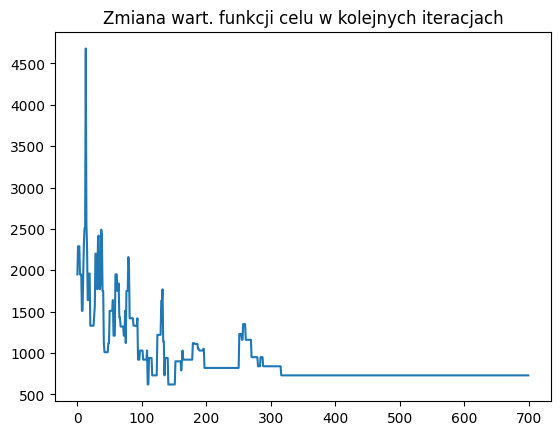

In [43]:
plt.plot(history_obj)
plt.title("Zmiana wart. funkcji celu w kolejnych iteracjach")
plt.show()